# Value at Risk and Conditional Value at Risk
**Docker image**: `ml4t`

## Purpose
Demonstrate VaR and CVaR computation methods—historical, parametric, Cornish-Fisher, and
Monte Carlo—on real ETF returns, then backtest them against realized losses, decompose
diversification benefit on a multi-asset portfolio, and contrast tail risk across volatility
regimes. These tail measures form the foundation for risk budgeting, exposure control, and
regulatory reporting.

## Learning Objectives
After completing this notebook, you will be able to:
- Compute VaR and CVaR with historical, parametric, Cornish-Fisher, and Monte Carlo methods
- Backtest VaR estimates with the Kupiec proportion-of-failures test
- Quantify the diversification benefit on a multi-asset ETF portfolio
- Decompose tail risk into volatility regimes and contrast forecast losses

## Book reference
- Section 19.3 — Measuring the Tail: VaR and CVaR
- Section 19.4 — Drawdowns, Path Risk, and Time-to-Recovery (drawdown context)

## Prerequisites
- Familiarity with daily return series and rolling volatility estimates
- Comfort reading quantile-based loss metrics and backtest exception counts

In [1]:
"""Value at Risk and Conditional Value at Risk on real ETF returns."""

import json
import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from arch import arch_model
from ml4t.diagnostic.evaluation.distribution import analyze_distribution, analyze_tails
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SYMBOL = "SPY"
SEED = 42
PORTFOLIO_SYMBOLS = ["SPY", "AGG", "GLD", "EFA", "EEM"]
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
ROLLING_WINDOW = 252
N_MC_SIMULATIONS = 10_000

In [3]:
OUTPUT_DIR = get_output_dir(19, "var_cvar")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
set_global_seeds(SEED)

## 1. Load ETF returns

We use SPY for the single-asset VaR analysis and a diversified five-ETF basket
(US equities, US aggregate bonds, gold, developed international, emerging markets)
for the portfolio-level diversification benefit.

In [5]:
etf_panel = (
    load_etfs()
    .filter(
        (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
        & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
        & pl.col("symbol").is_in(PORTFOLIO_SYMBOLS)
    )
    .sort(["symbol", "timestamp"])
)

returns_panel = (
    etf_panel.with_columns(ret=(pl.col("close") / pl.col("close").shift(1) - 1).over("symbol"))
    .drop_nulls("ret")
    .select(["timestamp", "symbol", "ret"])
)

# Single-asset path uses the full SPY history. The portfolio-VaR section below
# uses returns_wide, which intersects calendars across all five ETFs.
returns_spy = (
    returns_panel.filter(pl.col("symbol") == SYMBOL).sort("timestamp").select(["timestamp", "ret"])
)
returns_wide = returns_panel.pivot(values="ret", index="timestamp", on="symbol").drop_nulls()
print(f"Loaded {returns_spy.height:,} {SYMBOL} daily returns (single-asset path)")
print(
    f"Loaded {returns_wide.height:,} aligned daily returns across "
    f"{len(PORTFOLIO_SYMBOLS)} ETFs (portfolio path)"
)
print(f"  {SYMBOL}: {returns_spy['timestamp'].min()} to {returns_spy['timestamp'].max()}")
print(
    f"  Portfolio (aligned): {returns_wide['timestamp'].min()} to {returns_wide['timestamp'].max()}"
)

dates = returns_spy["timestamp"].to_numpy()
returns = returns_spy["ret"].to_numpy()
N_DAYS = len(returns)

Loaded 4,780 SPY daily returns (single-asset path)
Loaded 4,780 aligned daily returns across 5 ETFs (portfolio path)
  SPY: 2006-01-04 to 2024-12-31
  Portfolio (aligned): 2006-01-04 to 2024-12-31


In [6]:
summary_stats = pd.DataFrame(
    {
        "metric": ["Mean (%)", "Std (%)", "Skewness", "Excess kurtosis"],
        SYMBOL: [
            np.mean(returns) * 100,
            np.std(returns) * 100,
            stats.skew(returns),
            stats.kurtosis(returns),
        ],
    }
).round(4)
summary_stats

,metric,SPY
0,Mean (%),0.0470
1,Std (%),1.2209
2,Skewness,-0.0809
3,Excess kurtosis,14.5477


## 2. VaR Computation Methods

Each method recovers the same loss quantile from a different distributional lens.
Historical VaR is non-parametric, parametric VaR assumes Gaussian returns,
Cornish-Fisher adjusts the Gaussian quantile for skewness and kurtosis, and Monte
Carlo VaR samples from a fitted Student-t distribution to capture heavy tails.

### Historical VaR

Historical VaR uses the empirical return distribution without imposing a parametric shape.

In [7]:
def historical_var(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Historical (non-parametric) VaR: $\\text{VaR}_\\alpha = -q_{1-\\alpha}(r)$."""
    alpha = 1 - confidence
    return -np.percentile(returns, alpha * 100)

### Parametric VaR

Gaussian VaR provides a compact benchmark when we assume returns are approximately normal.

In [8]:
def parametric_var(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Parametric (Gaussian) VaR: $-\\mu + \\sigma\\,\\Phi^{-1}(1-\\alpha)$."""
    mu = np.mean(returns)
    sigma = np.std(returns)
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha)
    return -(mu - z * sigma)

### Cornish-Fisher VaR

Cornish-Fisher VaR adjusts the Gaussian quantile for skewness and kurtosis.

In [9]:
def cornish_fisher_var(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Cornish-Fisher VaR with a skew/kurtosis adjustment to the Gaussian quantile."""
    mu = np.mean(returns)
    sigma = np.std(returns)
    s = stats.skew(returns)
    k = stats.kurtosis(returns)

    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha)
    z_cf = z + (z**2 - 1) * s / 6 + (z**3 - 3 * z) * k / 24 - (2 * z**3 - 5 * z) * s**2 / 36
    return -(mu - z_cf * sigma)

### Monte Carlo VaR

Monte Carlo VaR estimates the loss threshold by simulating future paths from a fitted
Student-t distribution.

In [10]:
def monte_carlo_var(
    returns: np.ndarray,
    confidence: float = 0.95,
    n_simulations: int = N_MC_SIMULATIONS,
    horizon: int = 1,
    seed: int = 42,
) -> float:
    """Monte Carlo VaR by sampling from a fitted Student-t."""
    df, loc, scale = stats.t.fit(returns)
    rng = np.random.default_rng(seed)
    simulated = rng.standard_t(df, size=(n_simulations, horizon)) * scale + loc
    cumulative = simulated.sum(axis=1)
    alpha = 1 - confidence
    return -np.percentile(cumulative, alpha * 100)

### Method comparison

Across confidence levels, all four methods agree on the order of magnitude but differ in
how aggressively they assign mass to the tail. Cornish-Fisher and Monte Carlo lift the
99% VaR estimate above the Gaussian baseline because they incorporate the empirical
heavy tail of the SPY return distribution.

In [11]:
confidence_levels = [0.90, 0.95, 0.99]
var_results = []
for conf in confidence_levels:
    var_results.append(
        {
            "confidence": conf,
            "historical": historical_var(returns, conf) * 100,
            "parametric": parametric_var(returns, conf) * 100,
            "cornish_fisher": cornish_fisher_var(returns, conf) * 100,
            "monte_carlo": monte_carlo_var(returns, conf) * 100,
        }
    )
var_df = pd.DataFrame(var_results)
var_df.round(4)

,confidence,historical,parametric,cornish_fisher,monte_carlo
0,0.90,1.1844,1.5176,0.2199,1.0549
1,0.95,1.8081,1.9611,1.5745,1.6463
2,0.99,3.5592,2.7931,6.8697,3.7500


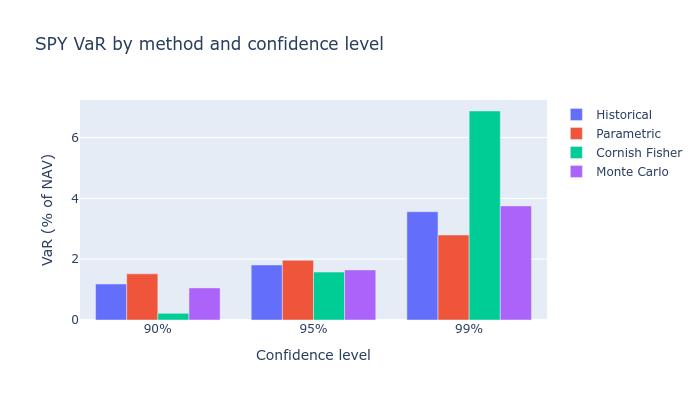

In [12]:
fig = go.Figure()
x = [f"{int(c * 100)}%" for c in confidence_levels]
for method in ["historical", "parametric", "cornish_fisher", "monte_carlo"]:
    fig.add_trace(go.Bar(x=x, y=var_df[method], name=method.replace("_", " ").title()))
fig.update_layout(
    title=f"{SYMBOL} VaR by method and confidence level",
    xaxis_title="Confidence level",
    yaxis_title="VaR (% of NAV)",
    barmode="group",
    height=400,
)
fig.show()

## 3. Conditional Value at Risk (CVaR / Expected Shortfall)

CVaR is the average loss conditional on a VaR breach. Unlike VaR, CVaR is subadditive
and provides full-tail information — both properties that make it the preferred
coherent risk measure when tail severity matters more than tail frequency.

### Historical CVaR

Historical CVaR averages the realized losses that fall beyond the VaR threshold.

In [13]:
def historical_cvar(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Historical CVaR (Expected Shortfall): $\\mathbb{E}[L \\mid L \\geq \\text{VaR}_\\alpha]$."""
    alpha = 1 - confidence
    var_q = np.percentile(returns, alpha * 100)
    tail_losses = returns[returns <= var_q]
    return -np.mean(tail_losses)

### Parametric CVaR

Parametric CVaR extends the Gaussian assumption to estimate expected tail losses analytically.

In [14]:
def parametric_cvar(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Parametric (Gaussian) CVaR: $-\\mu + \\sigma \\frac{\\phi(\\Phi^{-1}(1-\\alpha))}{\\alpha}$."""
    mu = np.mean(returns)
    sigma = np.std(returns)
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha)
    phi_z = stats.norm.pdf(z)
    return -(mu - sigma * phi_z / alpha)

### Student-t CVaR

Student-t CVaR captures heavier tails than the Gaussian alternative.

In [15]:
def student_t_cvar(returns: np.ndarray, confidence: float = 0.95) -> float:
    """CVaR under a fitted Student-t distribution (closed-form expression)."""
    df, loc, scale = stats.t.fit(returns)
    alpha = 1 - confidence
    t_val = stats.t.ppf(alpha, df)
    f_t = stats.t.pdf(t_val, df)
    return -loc + scale * (df + t_val**2) / ((df - 1) * alpha) * f_t

### Comparing VaR with CVaR

In [16]:
risk_measures = []
for conf in confidence_levels:
    risk_measures.append(
        {
            "confidence": conf,
            "var_historical": historical_var(returns, conf) * 100,
            "cvar_historical": historical_cvar(returns, conf) * 100,
            "var_parametric": parametric_var(returns, conf) * 100,
            "cvar_parametric": parametric_cvar(returns, conf) * 100,
            "cvar_student_t": student_t_cvar(returns, conf) * 100,
        }
    )
risk_df = pd.DataFrame(risk_measures)
risk_df.round(4)

,confidence,var_historical,cvar_historical,var_parametric,cvar_parametric,cvar_student_t
0,0.90,1.1844,2.2279,1.5176,2.0956,2.1665
1,0.95,1.8081,2.9930,1.9611,2.4713,3.0444
2,0.99,3.5592,5.2122,2.7931,3.2068,6.2648


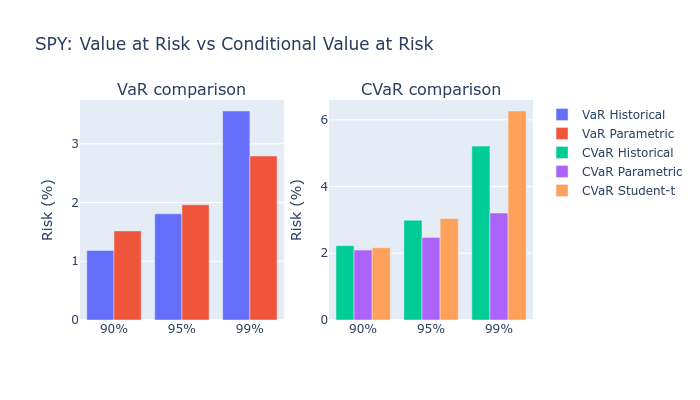

In [17]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["VaR comparison", "CVaR comparison"])
fig.add_trace(go.Bar(x=x, y=risk_df["var_historical"], name="VaR Historical"), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=risk_df["var_parametric"], name="VaR Parametric"), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=risk_df["cvar_historical"], name="CVaR Historical"), row=1, col=2)
fig.add_trace(go.Bar(x=x, y=risk_df["cvar_parametric"], name="CVaR Parametric"), row=1, col=2)
fig.add_trace(go.Bar(x=x, y=risk_df["cvar_student_t"], name="CVaR Student-t"), row=1, col=2)
fig.update_yaxes(title_text="Risk (%)", row=1, col=1)
fig.update_yaxes(title_text="Risk (%)", row=1, col=2)
fig.update_layout(
    title=f"{SYMBOL}: Value at Risk vs Conditional Value at Risk", barmode="group", height=400
)
fig.show()

CVaR systematically exceeds VaR at every confidence level, by a factor that grows in
the tail: the gap between Historical VaR(99%) and Historical CVaR(99%) is larger than
the corresponding gap at 90%. Student-t CVaR sits above the Gaussian estimate at deep
confidence, reflecting the heavier-tailed empirical distribution.

## 3.1 Cantelli Inequality: Distribution-Free Tail Bound

The Cantelli (one-sided Chebyshev) inequality provides a worst-case tail probability
requiring only finite mean and variance — no distributional assumptions:

$$P(X - \mu \geq k\sigma) \leq \frac{1}{1 + k^2}$$

This is much weaker than Gaussian bounds but applies to *any* distribution, making it
useful as a conservative stress benchmark when distribution assumptions are suspect.

In [18]:
k_values = [1.0, 1.5, 2.0, 3.0]
cantelli_df = pd.DataFrame(
    {
        "k": k_values,
        "Cantelli upper bound": [1.0 / (1.0 + k**2) for k in k_values],
        "Gaussian tail": [1.0 - stats.norm.cdf(k) for k in k_values],
    }
)
cantelli_df["Cantelli / Gaussian"] = (
    cantelli_df["Cantelli upper bound"] / cantelli_df["Gaussian tail"]
)
cantelli_df.round(4)

,k,Cantelli upper bound,Gaussian tail,Cantelli / Gaussian
0,1.0,0.5000,0.1587,3.1515
1,1.5,0.3077,0.0668,4.6057
2,2.0,0.2000,0.0228,8.7912
3,3.0,0.1000,0.0013,74.0797


At $k=2$, Cantelli gives a 20% tail probability vs Gaussian's 2.3%, an order of magnitude
more conservative. Empirical equity returns sit between the two: heavier-tailed than
Gaussian but never as extreme as the Cantelli worst case.

## 4. Distribution Analysis with ml4t-diagnostic

`analyze_distribution` and `analyze_tails` from `ml4t.diagnostic` package together the
moments, normality tests, Hill estimator, and QQ-plot diagnostics. This puts the
parametric / Cornish-Fisher / Student-t choice on an empirical footing.

In [19]:
dist_result = analyze_distribution(returns)
print(dist_result.summary())

2026-06-13 00:18:53,601 - ml4t.diagnostic.evaluation.distribution - INFO - Starting comprehensive distribution analysis (compute_tails=True alpha=0.05)


2026-06-13 00:18:53,602 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Computing distribution moments (n_obs=4780)


2026-06-13 00:18:53,602 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Computing distribution moments (n_obs=4780)


2026-06-13 00:18:53,603 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Moments computed (skewness=-0.08096319832510925 excess_kurtosis=14.564166268785243 skewness_sig=True excess_kurtosis_sig=True)


2026-06-13 00:18:53,603 - ml4t.diagnostic.evaluation.distribution.moments - INFO - Moments computed (skewness=-0.08096319832510925 excess_kurtosis=14.564166268785243 skewness_sig=True excess_kurtosis_sig=True)


...

2026-06-13 00:18:53,609 - ml4t.diagnostic.evaluation.distribution.tails - INFO - QQ plot data generated (distribution=t r_squared=0.9930260811121842)


2026-06-13 00:18:53,609 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Tail analysis completed (tail_index=2.861623851699345 classification=medium best_fit=t)


2026-06-13 00:18:53,609 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Tail analysis completed (tail_index=2.861623851699345 classification=medium best_fit=t)


2026-06-13 00:18:53,610 - ml4t.diagnostic.evaluation.distribution - INFO - Distribution analysis completed (is_normal=False recommended=t n_obs=4780)


COMPREHENSIVE DISTRIBUTION ANALYSIS
Sample Size:             4780
Mean:                    0.000470
Std Dev:                 0.012210

MOMENTS:
  Skewness:              -0.0810
                         (Significantly left-skewed)
  Excess Kurtosis:       14.5642
                         (Significantly fat tails)

NORMALITY TESTS:
  Jarque-Bera:           p=0.0000 (FAIL)
  Shapiro-Wilk:          p=0.0000 (FAIL)
  Consensus:             NON-NORMAL

TAIL ANALYSIS:
  Hill Tail Index:       2.8616
  Tail Classification:   MEDIUM
  Normal R²:             0.8697
  Student's t R²:        0.9930 (df=3)
  Best Fit:              T

RECOMMENDATION:
  Distribution:          T
  Degrees of Freedom:    3

INTERPRETATION:
  Data deviates from normality (at least one test rejects H0).
  Both normality tests reject H0.
  Significant negative skewness (-0.081) indicates left tail is heavier (common for equity returns).
  Significant excess kurtosis (14.564) indicates fat tails and higher extreme event pr

In [20]:
tail_result = analyze_tails(returns)
print(tail_result.summary())

2026-06-13 00:18:53,621 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Starting comprehensive tail analysis


2026-06-13 00:18:53,621 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Starting comprehensive tail analysis


2026-06-13 00:18:53,622 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Computing Hill estimator (n_obs=4780 k=69 tail=both)


2026-06-13 00:18:53,622 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Computing Hill estimator (n_obs=4780 k=69 tail=both)


2026-06-13 00:18:53,622 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Hill estimator computed (alpha=2.861623851699345 classification=medium k=69)


...

2026-06-13 00:18:53,625 - ml4t.diagnostic.evaluation.distribution.tails - INFO - QQ plot data generated (distribution=t r_squared=0.9930260811121842)


2026-06-13 00:18:53,625 - ml4t.diagnostic.evaluation.distribution.tails - INFO - QQ plot data generated (distribution=t r_squared=0.9930260811121842)


2026-06-13 00:18:53,625 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Tail analysis completed (tail_index=2.861623851699345 classification=medium best_fit=t)


2026-06-13 00:18:53,625 - ml4t.diagnostic.evaluation.distribution.tails - INFO - Tail analysis completed (tail_index=2.861623851699345 classification=medium best_fit=t)


Comprehensive Tail Analysis

TAIL INDEX ESTIMATION:
  Hill α:            2.8616
  Classification:    medium
  Tail Type:         both

DISTRIBUTION COMPARISON:
  Normal R²:         0.8697
  Student's t R²:    0.9930 (df=3)
  Best Fit:          t

INTERPRETATION:
  - Data best fit by Student's t (df=3)
  - Heavier tails than normal but finite variance
  - Moderate extreme event probability
  - Use robust statistical methods

RECOMMENDATIONS:
  - Use robust Sharpe ratio alternatives
  - Consider CVaR alongside VaR
  - Account for non-normality in models


## 5. VaR Backtesting

A VaR estimate is only as good as its empirical exception rate. The Kupiec
proportion-of-failures test compares the realized exception rate to the configured
coverage level under a binomial null.

### Kupiec proportion-of-failures test

In [21]:
def kupiec_test(exceptions: np.ndarray, expected_rate: float) -> tuple[float, float]:
    """Return the Kupiec likelihood-ratio statistic and its p-value."""
    n = len(exceptions)
    x = int(np.sum(exceptions))
    p = expected_rate
    if x == 0:
        lr = 2 * (n * np.log(1 - p))
    elif x == n:
        lr = 2 * (n * np.log(p))
    else:
        lr = 2 * (x * np.log(x / (n * p)) + (n - x) * np.log((n - x) / (n * (1 - p))))
    return lr, 1 - stats.chi2.cdf(lr, 1)

### Rolling VaR backtest helper

In [22]:
def backtest_var(
    returns: np.ndarray,
    window: int = ROLLING_WINDOW,
    confidence: float = 0.95,
    method: str = "historical",
) -> dict:
    """Backtest rolling VaR estimates against realized one-step losses."""
    var_func = {
        "historical": historical_var,
        "parametric": parametric_var,
        "cornish_fisher": cornish_fisher_var,
    }[method]

    var_estimates, exceptions = [], []
    for i in range(window, len(returns)):
        past = returns[i - window : i]
        v = var_func(past, confidence)
        var_estimates.append(v)
        exceptions.append(-returns[i] > v)

    var_estimates = np.array(var_estimates)
    exceptions = np.array(exceptions)
    n_exc = int(exceptions.sum())
    rate = n_exc / len(exceptions)
    expected = 1 - confidence
    lr, p_value = kupiec_test(exceptions, expected)

    return {
        "method": method,
        "confidence": confidence,
        "n_observations": len(exceptions),
        "n_exceptions": n_exc,
        "exception_rate": rate,
        "expected_rate": expected,
        "exception_ratio": rate / expected,
        "kupiec_lr": lr,
        "kupiec_pvalue": p_value,
        "var_estimates": var_estimates,
        "exceptions": exceptions,
    }

In [23]:
backtest_results = []
for method in ["historical", "parametric", "cornish_fisher"]:
    backtest_results.append(
        backtest_var(returns, window=ROLLING_WINDOW, confidence=0.95, method=method)
    )

backtest_summary = pd.DataFrame(
    [
        {
            "method": r["method"],
            "n_exceptions": r["n_exceptions"],
            "n_obs": r["n_observations"],
            "exception_rate": r["exception_rate"],
            "expected_rate": r["expected_rate"],
            "exception_ratio": r["exception_ratio"],
            "kupiec_pvalue": r["kupiec_pvalue"],
            "model_valid": r["kupiec_pvalue"] > 0.05,
        }
        for r in backtest_results
    ]
)
backtest_summary.round(4)

,method,n_exceptions,n_obs,exception_rate,expected_rate,exception_ratio,kupiec_pvalue,model_valid
0,historical,251,4528,0.0554,0.05,1.1087,0.0990,True
1,parametric,264,4528,0.0583,0.05,1.1661,0.0124,False
2,cornish_fisher,328,4528,0.0724,0.05,1.4488,0.0000,False


Whichever method produces the exception ratio closest to 1.0 with the
highest Kupiec p-value is the best calibrated risk model on this
sample. Historical VaR is best calibrated, with exception ratio
1.11 and Kupiec p ≈ 0.10 — the only method whose 95% tail rate is not
rejected at conventional levels. Parametric VaR underforecasts tail
losses (exception ratio 1.17, Kupiec p ≈ 0.012). Cornish-Fisher is
destabilised by the excess kurtosis of equity returns: rather than
stabilising the tail, the skew/kurtosis adjustment over-tightens the
quantile so the model breaches its budget 45% more often than expected
(exception ratio 1.45, Kupiec p ≈ 0).

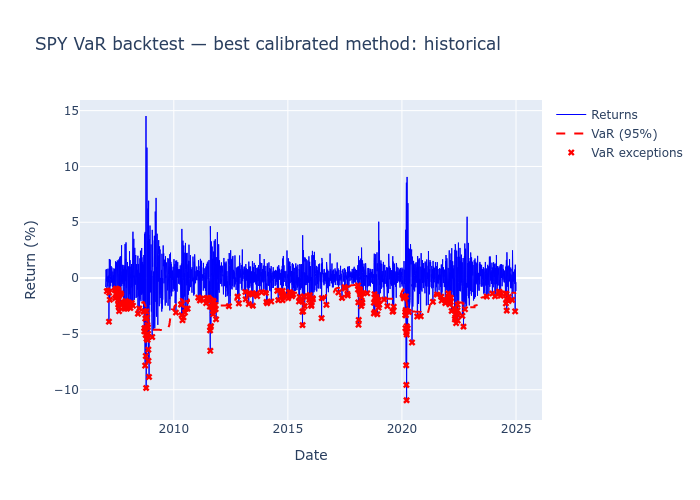

In [24]:
best_result = max(backtest_results, key=lambda r: r["kupiec_pvalue"])
test_dates = dates[ROLLING_WINDOW:]
test_returns = returns[ROLLING_WINDOW:]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=test_dates,
        y=test_returns * 100,
        mode="lines",
        name="Returns",
        line=dict(color="blue", width=1),
    )
)
fig.add_trace(
    go.Scatter(
        x=test_dates,
        y=-best_result["var_estimates"] * 100,
        mode="lines",
        name="VaR (95%)",
        line=dict(color="red", dash="dash"),
    )
)
mask = best_result["exceptions"]
fig.add_trace(
    go.Scatter(
        x=test_dates[mask],
        y=test_returns[mask] * 100,
        mode="markers",
        name="VaR exceptions",
        marker=dict(color="red", size=6, symbol="x"),
    )
)
fig.update_layout(
    title=f"{SYMBOL} VaR backtest — best calibrated method: {best_result['method']}",
    xaxis_title="Date",
    yaxis_title="Return (%)",
    height=500,
)
fig.show()

## 6. Rolling VaR and CVaR

In [25]:
rolling_var, rolling_cvar = [], []
for i in range(ROLLING_WINDOW, len(returns)):
    past = returns[i - ROLLING_WINDOW : i]
    rolling_var.append(historical_var(past, 0.95))
    rolling_cvar.append(historical_cvar(past, 0.95))
rolling_var = np.array(rolling_var)
rolling_cvar = np.array(rolling_cvar)
rolling_dates = dates[ROLLING_WINDOW:]

rolling_summary = pd.DataFrame(
    {
        "metric": ["Mean VaR(95%)", "Mean CVaR(95%)", "Mean CVaR/VaR ratio"],
        "value": [
            f"{np.mean(rolling_var) * 100:.3f}%",
            f"{np.mean(rolling_cvar) * 100:.3f}%",
            f"{np.mean(rolling_cvar) / np.mean(rolling_var):.2f}x",
        ],
    }
)
rolling_summary

,metric,value
0,Mean VaR(95%),1.839%
1,Mean CVaR(95%),2.635%
2,Mean CVaR/VaR ratio,1.43x


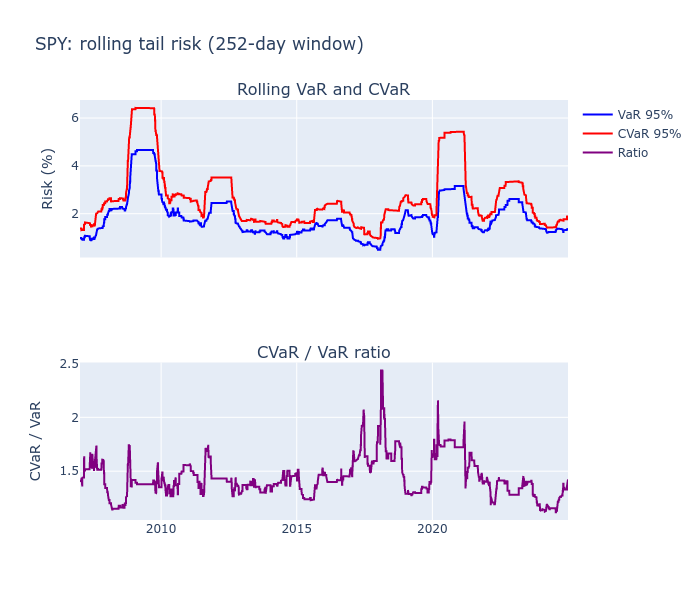

In [26]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, subplot_titles=["Rolling VaR and CVaR", "CVaR / VaR ratio"]
)
fig.add_trace(
    go.Scatter(
        x=rolling_dates, y=rolling_var * 100, mode="lines", name="VaR 95%", line=dict(color="blue")
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=rolling_dates, y=rolling_cvar * 100, mode="lines", name="CVaR 95%", line=dict(color="red")
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=rolling_dates,
        y=rolling_cvar / rolling_var,
        mode="lines",
        name="Ratio",
        line=dict(color="purple"),
    ),
    row=2,
    col=1,
)
fig.update_yaxes(title_text="Risk (%)", row=1, col=1)
fig.update_yaxes(title_text="CVaR / VaR", row=2, col=1)
fig.update_layout(title=f"{SYMBOL}: rolling tail risk ({ROLLING_WINDOW}-day window)", height=600)
fig.show()

## 6.1 Regime-Conditional VaR and CVaR

Unconditional VaR averages over regimes and masks the tail amplification that occurs
during high-volatility periods. We bucket trading days by trailing 63-day realized
volatility (terciles) and recompute VaR/CVaR within each regime.

In [27]:
returns_series = pd.Series(returns, index=pd.DatetimeIndex(dates))
rolling_vol_series = returns_series.rolling(63).std().dropna()
rolling_vol = rolling_vol_series.to_numpy()
vol_dates = rolling_vol_series.index
vol_returns = returns_series.loc[vol_dates].to_numpy()

vol_33 = np.percentile(rolling_vol, 33)
vol_67 = np.percentile(rolling_vol, 67)
regimes = np.where(
    rolling_vol <= vol_33, "Low Vol", np.where(rolling_vol <= vol_67, "Mid Vol", "High Vol")
)

regime_rows = []
regime_stats = {}
for regime in ["Low Vol", "Mid Vol", "High Vol"]:
    mask = regimes == regime
    regime_ret = vol_returns[mask]
    var_val = historical_var(regime_ret, 0.95) * 100
    cvar_val = historical_cvar(regime_ret, 0.95) * 100
    regime_stats[regime] = {"var": var_val, "cvar": cvar_val, "n": int(mask.sum())}
    regime_rows.append(
        {
            "regime": regime,
            "n_days": int(mask.sum()),
            "var_95_pct": var_val,
            "cvar_95_pct": cvar_val,
            "cvar_var_ratio": cvar_val / var_val,
        }
    )
regime_df = pd.DataFrame(regime_rows)
regime_df.round(3)

,regime,n_days,var_95_pct,cvar_95_pct,cvar_var_ratio
0,Low Vol,1557,1.145,1.627,1.421
1,Mid Vol,1604,1.487,2.225,1.496
2,High Vol,1557,2.742,4.330,1.579


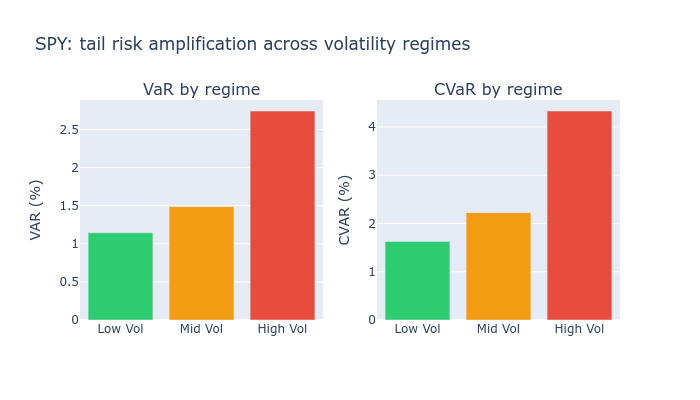

In [28]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["VaR by regime", "CVaR by regime"])
regime_names = list(regime_stats.keys())
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for col_i, metric in enumerate(["var", "cvar"], 1):
    vals = [regime_stats[r][metric] for r in regime_names]
    fig.add_trace(
        go.Bar(x=regime_names, y=vals, marker_color=colors, showlegend=False),
        row=1,
        col=col_i,
    )
    fig.update_yaxes(title_text=f"{metric.upper()} (%)", row=1, col=col_i)
fig.update_layout(title=f"{SYMBOL}: tail risk amplification across volatility regimes", height=400)
fig.show()

Both VaR and CVaR rise sharply from the low- to high-volatility regime
— CVaR climbs from $1.63\%$ in Low Vol to $4.33\%$ in High Vol, a
2.7× amplification — and the CVaR/VaR ratio also expands from
$1.42$ to $1.58$. High-volatility days bring not just larger
expected losses but a fatter conditional tail. Position-sizing rules
that scale inversely to conditional CVaR react to this regime shift,
while controls calibrated to unconditional VaR can underprovision risk
capital just when it is most needed.

## 6.2 Drawdown depth and time-to-recovery

VaR and CVaR are point-loss measures; drawdowns capture *path* risk — how deep the
losses go and how long the recovery takes. For the same underlying return series,
drawdowns and tail measures stress different aspects of the same distribution.

In [29]:
def drawdown_path(returns: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return cumulative wealth, running peak, and drawdown (negative %) series."""
    wealth = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(wealth)
    dd = wealth / peak - 1
    return wealth, peak, dd


wealth, peak, drawdown = drawdown_path(returns)
max_dd = float(drawdown.min())
max_dd_idx = int(drawdown.argmin())
peak_idx = int(np.argmax(wealth[: max_dd_idx + 1]))
recovery_offset = np.where(wealth[max_dd_idx:] >= peak[max_dd_idx])[0]
recovery_idx = int(max_dd_idx + recovery_offset[0]) if recovery_offset.size else None

drawdown_summary = pd.DataFrame(
    {
        "metric": [
            "Max drawdown",
            "Max-drawdown trough date",
            "Prior peak date",
            "Recovery date",
            "Drawdown duration (trading days)",
            "Recovery duration (trading days)",
        ],
        "value": [
            f"{max_dd * 100:.2f}%",
            str(pd.Timestamp(dates[max_dd_idx]).date()),
            str(pd.Timestamp(dates[peak_idx]).date()),
            str(pd.Timestamp(dates[recovery_idx]).date())
            if recovery_idx is not None
            else "not recovered in sample",
            max_dd_idx - peak_idx,
            (recovery_idx - max_dd_idx) if recovery_idx is not None else None,
        ],
    }
)
drawdown_summary

,metric,value
0,Max drawdown,-55.19%
1,Max-drawdown trough date,2009-03-09
2,Prior peak date,2007-10-09
3,Recovery date,2012-08-16
4,Drawdown duration (trading days),355
5,Recovery duration (trading days),869


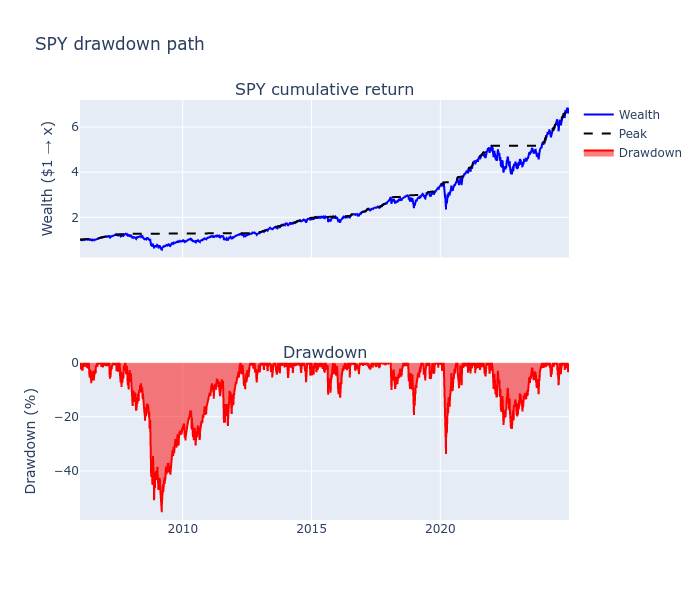

In [30]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, subplot_titles=[f"{SYMBOL} cumulative return", "Drawdown"]
)
fig.add_trace(
    go.Scatter(x=dates, y=wealth, mode="lines", name="Wealth", line=dict(color="blue")),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=dates, y=peak, mode="lines", name="Peak", line=dict(color="black", dash="dash")),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=drawdown * 100,
        mode="lines",
        name="Drawdown",
        fill="tozeroy",
        line=dict(color="red"),
    ),
    row=2,
    col=1,
)
fig.update_yaxes(title_text="Wealth ($1 → x)", row=1, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)
fig.update_layout(title=f"{SYMBOL} drawdown path", height=600, showlegend=True)
fig.show()

Maximum drawdown is the worst-case path loss in the sample; the trough-to-recovery
duration is the operational pain that allocators and risk officers actually live
through. Tail metrics (CVaR) and path metrics (max drawdown) tend to move together
but the path metric responds to the *sequence* of losses — two distributions with
identical CVaR can produce very different drawdown experiences.

## 7. Portfolio VaR — Diversification Benefit

A diversified portfolio's VaR is bounded above by the weighted sum of stand-alone
component VaRs. The gap is the diversification benefit. Because correlations rise in
stress, this benefit is itself state-dependent — the same five-asset basket carries
different effective tail risk in calm and stressed regimes.

In [31]:
def portfolio_var(
    returns_matrix: np.ndarray,
    weights: np.ndarray,
    confidence: float = 0.95,
) -> dict:
    """Compute diversified and undiversified portfolio VaR side by side."""
    portfolio_returns = returns_matrix @ weights
    individual = np.array(
        [historical_var(returns_matrix[:, i], confidence) for i in range(returns_matrix.shape[1])]
    )
    undiversified = float(np.sum(weights * individual))
    diversified = float(historical_var(portfolio_returns, confidence))
    benefit = 1 - diversified / undiversified
    return {
        "portfolio_var": diversified,
        "undiversified_var": undiversified,
        "diversification_benefit": benefit,
        "individual_vars": individual,
        "portfolio_returns": portfolio_returns,
    }

In [32]:
asset_returns = returns_wide.select(PORTFOLIO_SYMBOLS).to_numpy()
weights = np.ones(len(PORTFOLIO_SYMBOLS)) / len(PORTFOLIO_SYMBOLS)
port_var_result = portfolio_var(asset_returns, weights, confidence=0.95)

portfolio_summary = pd.DataFrame(
    {
        "metric": ["Diversified VaR(95%)", "Undiversified VaR(95%)", "Diversification benefit"],
        "value": [
            f"{port_var_result['portfolio_var'] * 100:.3f}%",
            f"{port_var_result['undiversified_var'] * 100:.3f}%",
            f"{port_var_result['diversification_benefit'] * 100:.1f}%",
        ],
    }
)
portfolio_summary

,metric,value
0,Diversified VaR(95%),1.301%
1,Undiversified VaR(95%),1.709%
2,Diversification benefit,23.9%


In [33]:
component_df = pd.DataFrame(
    {
        "symbol": PORTFOLIO_SYMBOLS,
        "weight": weights,
        "var_95_pct": port_var_result["individual_vars"] * 100,
    }
).round(4)
component_df

,symbol,weight,var_95_pct
0,SPY,0.2,1.8081
1,AGG,0.2,0.4636
2,GLD,0.2,1.7712
3,EFA,0.2,2.0148
4,EEM,0.2,2.4883


On the five-asset basket the diversified portfolio VaR of $1.30\%$ sits
23.9% below the undiversified weighted-component VaR of $1.71\%$ — that
gap is the diversification benefit. It is *unconditional*: the same
basket shows a much smaller benefit in stressed regimes because
correlations rise precisely when diversification would be most useful.

## 8. Volatility Forecast Evaluation: QLIKE and MSE

Risk management depends on accurate volatility forecasts. Two complementary loss
functions evaluate forecast quality:

$$\text{MSE} = \frac{1}{T}\sum_{t=1}^T (\hat{\sigma}_t^2 - \sigma_t^2)^2$$

$$\text{QLIKE} = \frac{1}{T}\sum_{t=1}^T \left[\log(\hat{\sigma}_t^2) + \frac{\sigma_t^2}{\hat{\sigma}_t^2}\right]$$

QLIKE's asymmetric penalty makes it more appropriate for risk: under-predicting
volatility (dangerous for risk management) is penalized more than over-predicting.
We use squared daily returns as the volatility proxy $\sigma_t^2$. See Chapter 9 for
deeper GARCH treatment; here we use a compact GARCH(1,1) fit solely for comparison.

### QLIKE Loss

QLIKE penalizes under-forecasting volatility more sharply than over-forecasting it.

In [34]:
def qlike_loss(forecast_var: np.ndarray, proxy_var: np.ndarray) -> float:
    """QLIKE loss: $\\log(\\hat{\\sigma}^2) + \\sigma^2_{\\text{proxy}} / \\hat{\\sigma}^2$."""
    mask = (forecast_var > 0) & (proxy_var > 0)
    f, p = forecast_var[mask], proxy_var[mask]
    return float(np.mean(np.log(f) + p / f))

### Variance MSE

MSE provides a symmetric baseline loss for volatility forecast comparison.

In [35]:
def variance_mse(forecast_var: np.ndarray, proxy_var: np.ndarray) -> float:
    """Variance MSE: $(\\hat{\\sigma}^2 - \\sigma^2_{\\text{proxy}})^2$."""
    return float(np.mean((forecast_var - proxy_var) ** 2))

In [36]:
ret_series = pd.Series(returns, index=pd.DatetimeIndex(dates))
proxy_var = ret_series**2

# Forecast variance for day t comes from information up to day t-1, so we
# shift every conditional-variance series by one day before scoring it
# against the squared-return proxy. The GARCH(1,1) fit below is full-sample
# (compact, for comparison only — see Chapter 9 for deeper / walk-forward
# GARCH); the one-day shift converts the in-sample conditional volatility
# into a lagged volatility estimate that is at least available before the
# realised return.
rolling_var_21 = ret_series.rolling(21).var().shift(1).dropna()
ewma_var = ret_series.ewm(alpha=0.06).var().shift(1).dropna()
garch_model = arch_model(ret_series * 100, vol="Garch", p=1, q=1, dist="normal")
garch_fit = garch_model.fit(disp="off")
garch_var = ((garch_fit.conditional_volatility / 100) ** 2).shift(1).dropna()

common_idx = rolling_var_21.index.intersection(ewma_var.index).intersection(garch_var.index)
proxy_aligned = proxy_var.loc[common_idx].values
rolling_aligned = rolling_var_21.loc[common_idx].values
ewma_aligned = ewma_var.loc[common_idx].values
garch_aligned = garch_var.loc[common_idx].values

forecast_eval_df = pd.DataFrame(
    [
        {
            "method": name,
            "qlike": qlike_loss(fcast, proxy_aligned),
            "mse_x_1e6": variance_mse(fcast, proxy_aligned) * 1e6,
        }
        for name, fcast in [
            ("Rolling 21d", rolling_aligned),
            ("EWMA λ=0.94", ewma_aligned),
            ("GARCH(1,1)", garch_aligned),
        ]
    ]
)
forecast_eval_df.round(4)

,method,qlike,mse_x_1e6
0,Rolling 21d,-8.2371,0.3150
1,EWMA λ=0.94,-8.3048,0.3046
2,"GARCH(1,1)",-8.3515,0.2819


Lower QLIKE and lower MSE both indicate a better forecast. On this SPY
sample the one-day-lagged GARCH(1,1) posts the lowest QLIKE ($-8.35$) and
the lowest MSE ($0.28 \times 10^{-6}$), edging out EWMA with the 21-day
rolling variance last. Two caveats keep this from being a forecast
verdict: the GARCH(1,1) is fit once on the full sample with Gaussian
innovations (a compact comparison, not the walk-forward, Student-t refit
of *Chapter 9*), and the squared-return proxy $\sigma_t^2$ is noisy enough
that the GARCH–EWMA QLIKE gap ($\approx 0.05$) sits within sampling error
on a single $\sim$20-year window. Read the table as "all three track
realised variance, GARCH and EWMA more closely than rolling," not as a
ranking. QLIKE is still the more relevant loss for risk management because
methods that under-predict during crises score worse than those that
over-predict.

## 9. Save artefacts for downstream chapters

In [37]:
var_comparison_df = pl.DataFrame(
    {
        "confidence": [f"{int(c * 100)}%" for c in confidence_levels] * 4,
        "method": ["historical"] * 3
        + ["parametric"] * 3
        + ["cornish_fisher"] * 3
        + ["monte_carlo"] * 3,
        "var_pct": list(var_df["historical"])
        + list(var_df["parametric"])
        + list(var_df["cornish_fisher"])
        + list(var_df["monte_carlo"]),
    }
)
var_cvar_df = pl.from_pandas(risk_df)
backtest_df = pl.DataFrame(
    {
        "method": [r["method"] for r in backtest_results],
        "n_exceptions": [r["n_exceptions"] for r in backtest_results],
        "n_observations": [r["n_observations"] for r in backtest_results],
        "exception_rate": [r["exception_rate"] for r in backtest_results],
        "expected_rate": [r["expected_rate"] for r in backtest_results],
        "exception_ratio": [r["exception_ratio"] for r in backtest_results],
        "kupiec_pvalue": [r["kupiec_pvalue"] for r in backtest_results],
    }
)
rolling_risk_df = pl.DataFrame(
    {
        "timestamp": pd.DatetimeIndex(rolling_dates).to_pydatetime().tolist(),
        "var_95": rolling_var.tolist(),
        "cvar_95": rolling_cvar.tolist(),
        "cvar_var_ratio": (rolling_cvar / rolling_var).tolist(),
    }
)
regime_pl = pl.from_pandas(regime_df)

best_bt = max(backtest_results, key=lambda r: r["kupiec_pvalue"])
methodology_metadata = {
    "symbol": SYMBOL,
    "portfolio_symbols": PORTFOLIO_SYMBOLS,
    "start_date": str(returns_wide["timestamp"].min()),
    "end_date": str(returns_wide["timestamp"].max()),
    "n_days": int(N_DAYS),
    "return_skewness": float(stats.skew(returns)),
    "return_kurtosis": float(stats.kurtosis(returns)),
    "is_non_normal": bool(abs(stats.skew(returns)) > 0.5 or stats.kurtosis(returns) > 1),
    "avg_var_95": float(np.mean(rolling_var)),
    "avg_cvar_95": float(np.mean(rolling_cvar)),
    "cvar_var_ratio": float(np.mean(rolling_cvar) / np.mean(rolling_var)),
    "diversification_benefit": float(port_var_result["diversification_benefit"]),
    "best_backtest_method": best_bt["method"],
    "kupiec_pvalue_best": float(best_bt["kupiec_pvalue"]),
    "regime_low_vol_cvar_pct": float(regime_stats["Low Vol"]["cvar"]),
    "regime_high_vol_cvar_pct": float(regime_stats["High Vol"]["cvar"]),
    "max_drawdown_pct": float(max_dd * 100),
    "drawdown_duration_days": int(max_dd_idx - peak_idx),
    "recovery_duration_days": (
        int(recovery_idx - max_dd_idx) if recovery_idx is not None else None
    ),
}

var_comparison_df.write_parquet(OUTPUT_DIR / "var_method_comparison.parquet")
var_cvar_df.write_parquet(OUTPUT_DIR / "var_cvar_comparison.parquet")
backtest_df.write_parquet(OUTPUT_DIR / "var_backtest_results.parquet")
rolling_risk_df.write_parquet(OUTPUT_DIR / "rolling_risk_metrics.parquet")
regime_pl.write_parquet(OUTPUT_DIR / "regime_conditional_risk.parquet")

with open(OUTPUT_DIR / "var_methodology_metadata.json", "w") as f:
    json.dump(methodology_metadata, f, indent=2)

print(f"[OK] VaR/CVaR artefacts saved to {OUTPUT_DIR}")
print(f"  - var_method_comparison.parquet: {len(var_comparison_df)} rows")
print(f"  - var_cvar_comparison.parquet:   {len(var_cvar_df)} rows")
print(f"  - var_backtest_results.parquet:  {len(backtest_df)} methods")
print(f"  - rolling_risk_metrics.parquet:  {len(rolling_risk_df)} days")
print(f"  - regime_conditional_risk.parquet: {len(regime_pl)} regimes")

[OK] VaR/CVaR artefacts saved to 19_risk_management/output/var_cvar
  - var_method_comparison.parquet: 12 rows
  - var_cvar_comparison.parquet:   3 rows
  - var_backtest_results.parquet:  3 methods
  - rolling_risk_metrics.parquet:  4528 days
  - regime_conditional_risk.parquet: 3 regimes


## 10. Key Takeaways

1. **Historical VaR is best calibrated on this SPY sample.** Exception
   ratio 1.11 with Kupiec p ≈ 0.10 — the only method whose realised tail
   exception rate is not rejected at conventional levels. Parametric VaR
   underforecasts; Cornish-Fisher's skew/kurtosis adjustment is
   destabilised by the heavy tail and fails most strongly.
2. **CVaR strictly dominates VaR as a coherent risk measure.** It is
   subadditive, captures full tail severity, and is convex — preferred
   for portfolio optimisation with tail constraints. Diversification
   benefit on a five-asset basket is real but shrinks when correlations
   rise in stress, precisely when it is needed most.
3. **Distributional adjustments matter at deep confidence.** At 99% the
   Cornish-Fisher and Student-t MC estimates diverge meaningfully from
   the Gaussian baseline; ignore the heavy tail and the 99% number
   under-reserves risk capital.
4. **Regime-conditional tail risk drives position sizing.** High-volatility
   VaR/CVaR is meaningfully larger than low-volatility values, and the
   CVaR/VaR ratio also expands; ignoring regime structure under-provisions
   risk capital in stress.
5. **Backtest the model, not just the metric.** The Kupiec test
   discriminates between methods that look similar at average-day
   quantiles but differ in their realised exception rates over
   multi-year windows.

**Next**: [`06_stress_testing`](06_stress_testing.ipynb) challenges
these tail-risk estimates with named historical crises and constructed
shocks.